# Load dataset from DB

In [154]:
import sys
import os

sys.path.append("../backend")

from extract_data import get_data_from_db

# 로컬 테스트를 위해 부모 디렉토리의 .env 파일을 찾아 수동으로 환경변수 세팅
env_path = 'C:\dev\SKN27-2nd-2TEAM\.env'
if os.path.exists(env_path):
    with open(env_path, 'r') as f:
        for line in f:
            if line.strip() and not line.startswith('#'):
                key, value = line.strip().split('=', 1)
                os.environ[key] = value

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\2657942140.py:9: SyntaxWarning: invalid escape sequence '\d'
  env_path = 'C:\dev\SKN27-2nd-2TEAM\.env'


In [155]:
user_df = get_data_from_db("SELECT * FROM users")
movie_df = get_data_from_db("SELECT * FROM movies")
rec_df = get_data_from_db("SELECT * FROM recommendation_logs")
review_df = get_data_from_db("SELECT * FROM reviews")
watch_df = get_data_from_db("SELECT * FROM watch_history")
search_df = get_data_from_db("SELECT * FROM search_logs")

DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공
DB 연결 성공


# 데이터 전처리 및 EDA

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme()

#### Train / Test split

In [157]:
from sklearn.model_selection import train_test_split

user_df['churned'] = 1 - user_df['is_active']
y = user_df['churned']
X = user_df.drop(['is_active', 'churned'], axis=1)

drop_cols = ['email', 'first_name', 'last_name', 'city', 'created_at']
X = X.drop(drop_cols, axis=1)
X.head()

,user_id,age,gender,country,state_province,subscription_plan,subscription_start_date,monthly_spend,primary_device,household_size
0,1,43.0,Male,USA,Massachusetts,Basic,2024-04-08,36.06,Laptop,1.0
1,2,38.0,Male,USA,Texas,Premium+,2024-05-24,14.59,Desktop,2.0
2,3,32.0,Female,USA,Michigan,Standard,2023-09-22,11.71,Desktop,3.0
3,4,11.0,Male,USA,Ohio,Standard,2024-08-21,28.56,Laptop,2.0
4,5,21.0,Female,USA,Arizona,Standard,2024-10-28,9.54,Desktop,6.0


In [158]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
train = pd.concat([X_tr, y_tr], axis=1)
test = pd.concat([X_te, y_te], axis=1)

X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((8000, 10), (2000, 10), (8000,), (2000,))

#### 타겟값 분포 확인 -> 데이터 불균형 존재

<Axes: xlabel='churned', ylabel='count'>

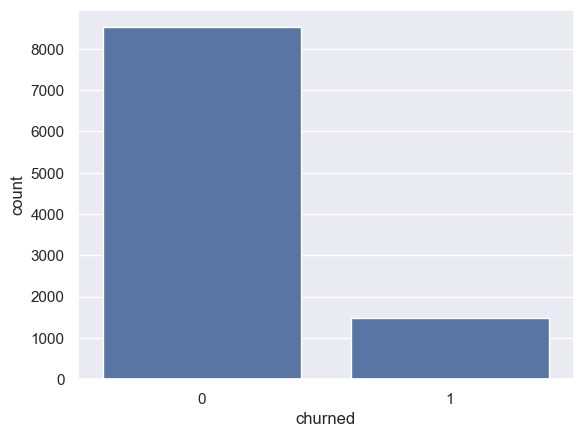

In [159]:
sns.countplot(user_df, x='churned')

#### age 분포
- 평균과 중간값이 모두 35
- 나이가 음수인 데이터와 지나치게 높은 데이터 존재
- 범위를 0에서 70으로 제한

count    7031.000000
mean       34.982933
std        12.518424
min        -7.000000
25%        27.000000
50%        35.000000
75%        43.000000
max       109.000000
Name: age, dtype: float64


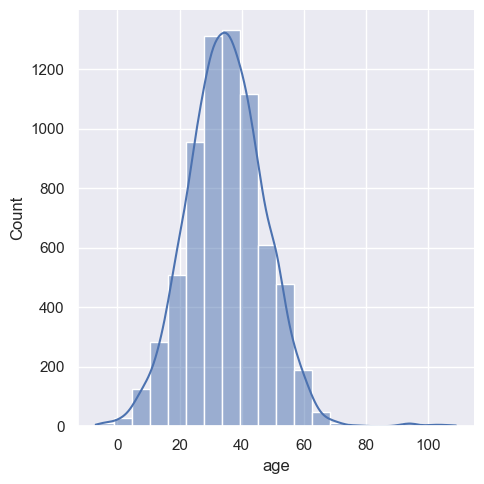

In [160]:
print(train['age'].describe())
sns.displot(data=train, x='age', bins=20, kde=True)

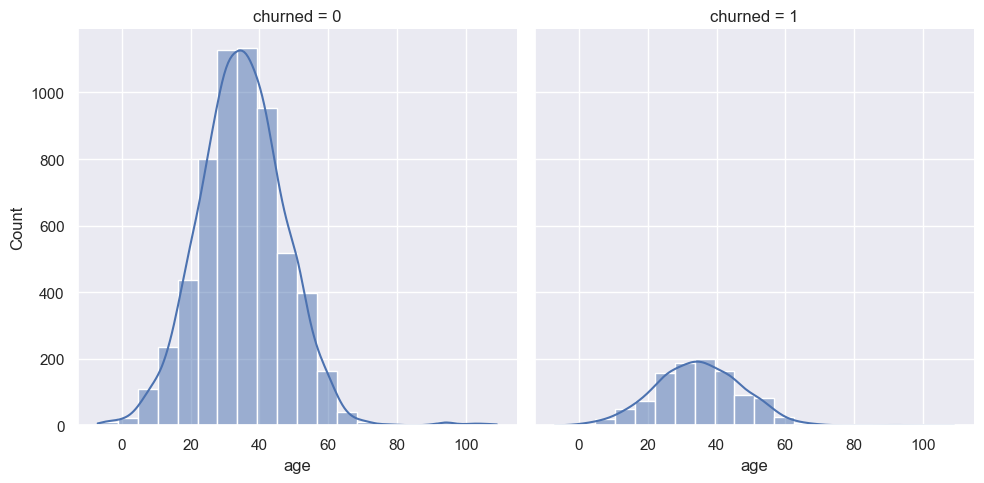

In [161]:
sns.displot(data=train, x='age', col='churned', bins=20, multiple='dodge', kde=True)

#### gender 분포
- 남성, 여성 외에 성별을 입력하지 않은 상태 존재
- 각 성별군마다 churned 상의 큰 차이는 확인하기 어려움

gender
Female               3382
Male                 3274
Other                 368
Prefer not to say     356
Name: count, dtype: int64


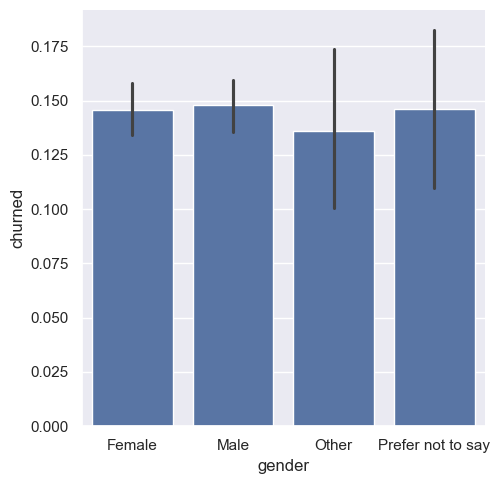

In [162]:
print(train['gender'].value_counts())
sns.catplot(data=train, x='gender', y='churned', kind='bar')

#### country & state_province 분포
- 2개 카테고리(미국, 캐나다) 간의 눈에 띄는 차이는 보이지 않음
- state_province: 30개 주가 명목형으로 기록되어 있고, 주마다 churned의 약간씩 차이 있음

country
USA       5576
Canada    2424
Name: count, dtype: int64


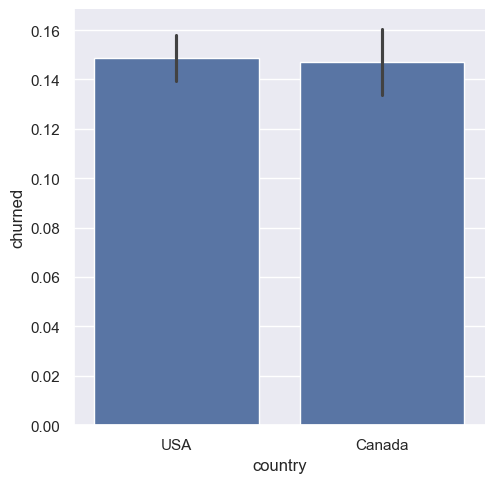

In [163]:
print(train.country.value_counts())
sns.catplot(data=train, x='country', y='churned', kind='bar')

30


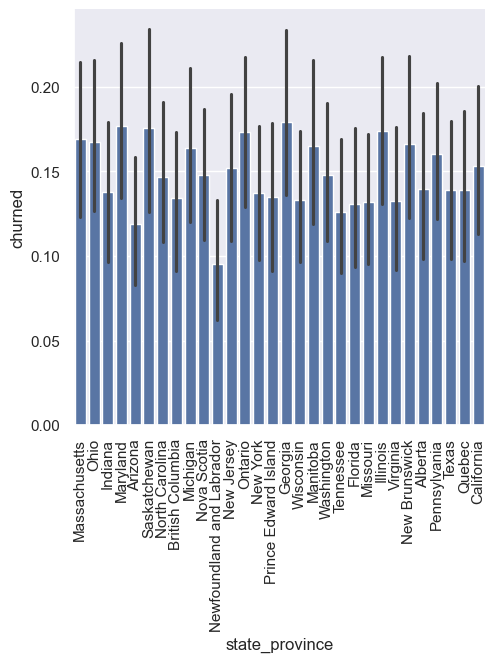

In [164]:
print(train.state_province.nunique())
sns.catplot(data=train, x='state_province', y='churned', kind='bar')
plt.xticks(rotation=90)
plt.show()

#### subscription & monthly_spend 분포
- subscription_plan: Basic, Standard, Premium, Premium+ 의 4가지 플랜
- monthly_spend: 매우 불균형한 분포 -> 이상치 처리 없이는 두 변수 사이의 관계를 확인하기 어려움

subscription_plan
Standard    2811
Premium     2778
Basic       1594
Premium+     817
Name: count, dtype: int64


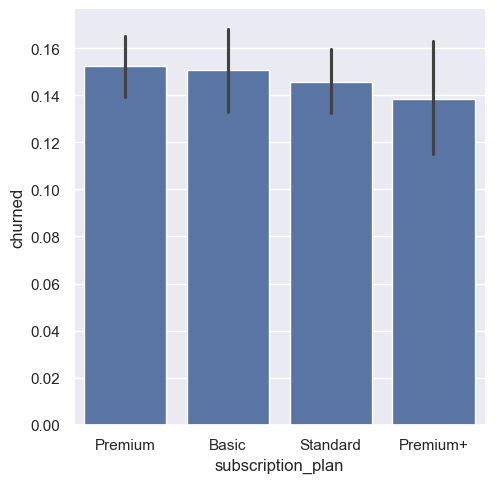

In [165]:
print(train.subscription_plan.value_counts())

sns.catplot(data=train, x='subscription_plan', y='churned', kind='bar')

count    7205.000000
mean       22.480046
std        68.191251
min         0.110000
25%         7.780000
50%        13.590000
75%        21.670000
max       997.800000
Name: monthly_spend, dtype: float64


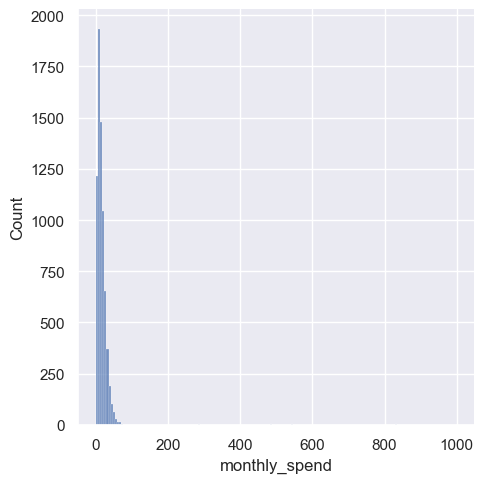

In [166]:
print(train.monthly_spend.describe())
sns.displot(data=train, x='monthly_spend')

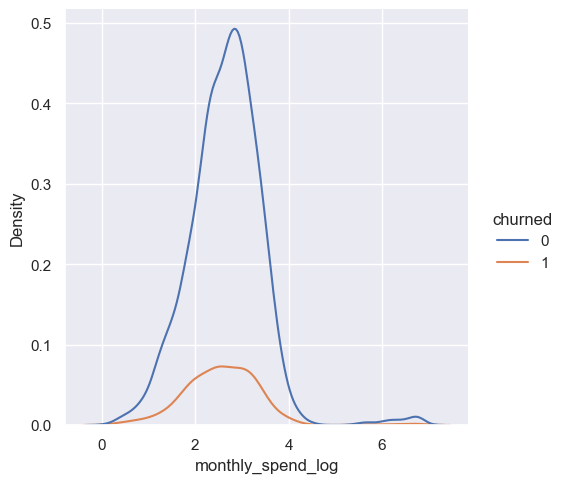

In [167]:
train['monthly_spend_log'] = np.log1p(train['monthly_spend'])
sns.displot(data=train, x='monthly_spend_log', hue='churned', kind='kde')

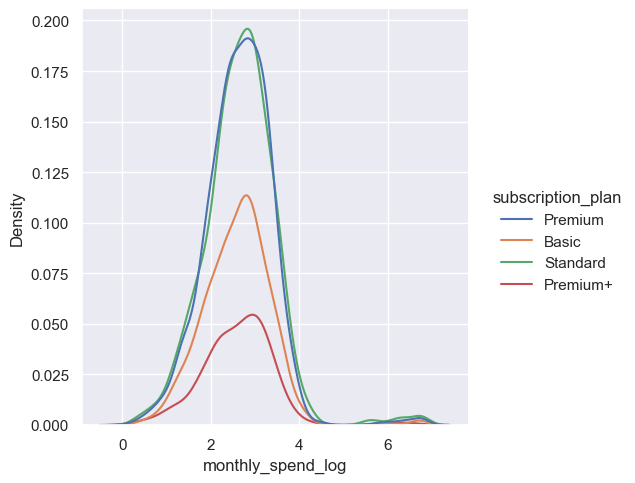

In [168]:
sns.displot(data=train, x='monthly_spend_log', hue='subscription_plan', kind='kde')

#### device & household_size 분포
- primary_device: 'Mobile' 'Desktop' 'Smart TV' 'Laptop' 'Tablet' 'Gaming Console' -> 6개 카테고리
- household_size: 가구 수 정보; 순서 동일

primary_device
Desktop           1408
Laptop            1340
Tablet            1339
Smart TV          1329
Gaming Console    1295
Mobile            1289
Name: count, dtype: int64


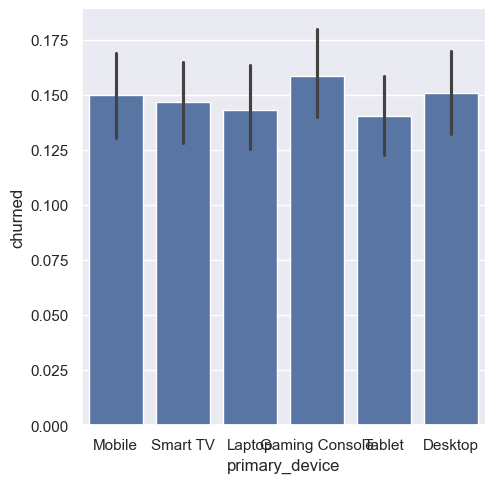

In [169]:
print(train.primary_device.value_counts())
sns.catplot(data=train, x='primary_device', y='churned', kind='bar')

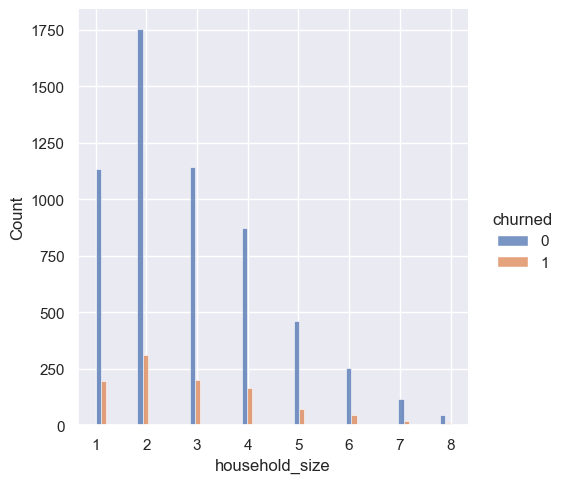

In [170]:
sns.displot(data=train, x='household_size', hue='churned', multiple='dodge')

### 이상치 처리

#### age -> 제거

            user_id          age  monthly_spend  household_size      churned  \
count   6769.000000  6769.000000    6089.000000     5738.000000  6769.000000   
mean    4984.940021    34.947850      21.755898        2.854479     0.151130   
std     2910.389438    10.934339      64.489637        1.554960     0.358202   
min        1.000000    10.000000       0.110000        1.000000     0.000000   
25%     2450.000000    27.000000       7.680000        2.000000     0.000000   
50%     4971.000000    35.000000      13.480000        2.000000     0.000000   
75%     7522.000000    43.000000      21.440000        4.000000     0.000000   
max    10000.000000    60.000000     997.800000        8.000000     1.000000   

       monthly_spend_log  
count        6089.000000  
mean            2.634642  
std             0.789058  
min             0.104360  
25%             2.161022  
50%             2.672768  
75%             3.110845  
max             6.906555  


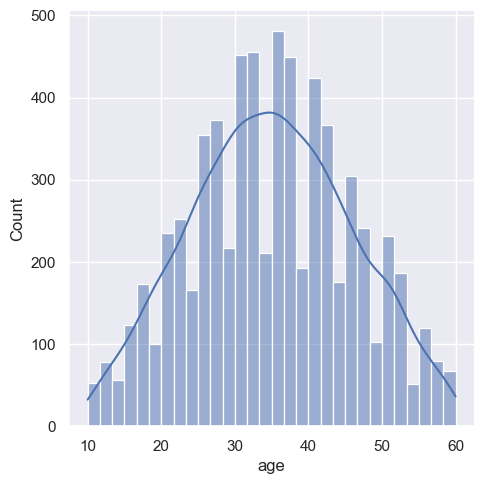

In [171]:
# age
age_mean = train['age'].mean()
age_std = train['age'].std()
train = train[(train['age'] >= age_mean - 2 * age_std) & (train['age'] <= age_mean + 2 * age_std)]
test = test[(test['age'] >= age_mean - 2 * age_std) & (test['age'] <= age_mean + 2 * age_std)]
print(train.describe())

sns.displot(data=train, x='age', kde=True)

## 결측치 처리

In [172]:
round(train.isnull().sum() / len(train), 3) * 100

user_id                     0.0
age                         0.0
gender                      7.8
country                     0.0
state_province              0.0
subscription_plan           0.0
subscription_start_date     0.0
monthly_spend              10.0
primary_device              0.0
household_size             15.2
churned                     0.0
monthly_spend_log          10.0
dtype: float64

subscription_plan
Standard    2373
Premium     2366
Basic       1343
Premium+     687
Name: count, dtype: int64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\2694088436.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['gender'] = train['gender'].map(lambda x: proc_gender(x))


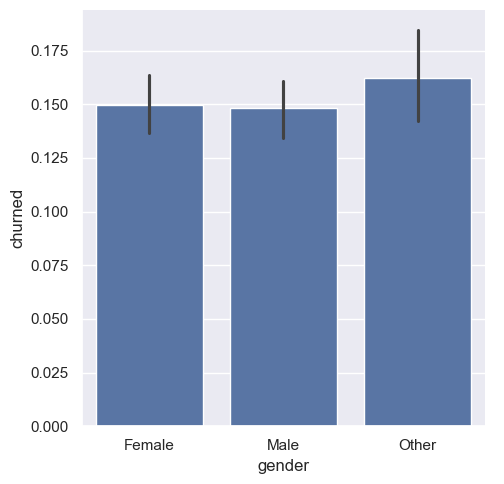

In [173]:
# 성별
def proc_gender(x):
    if x in ['Male', 'Female']:
        return x
    else:
        return 'Other'
train['gender'] = train['gender'].map(lambda x: proc_gender(x))
test['gender'] = test['gender'].map(lambda x: proc_gender(x))

print(train.subscription_plan.value_counts())

sns.catplot(data=train, x='gender', y='churned', kind='bar')

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\3817907440.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['monthly_spend'] = train['monthly_spend'].fillna(
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\3817907440.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['monthly_spend_log'] = np.log1p(train['monthly_spend'])


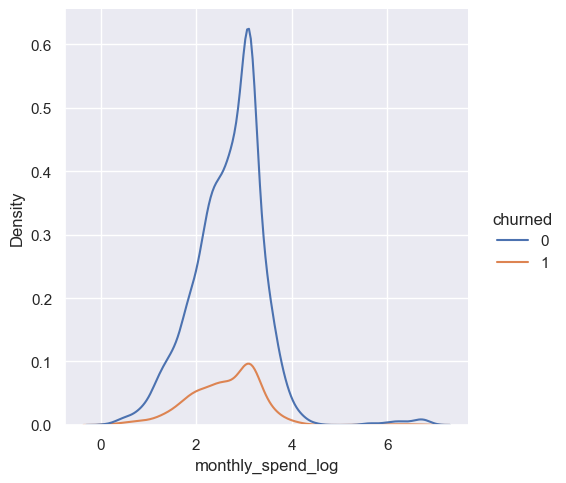

In [174]:
# monthly_spend -> log 변환
# 1. train에서만 subscription_plan별 평균 계산
plan_spend_mean = train.groupby('subscription_plan')['monthly_spend'].mean()

# 2. train에 적용
train['monthly_spend'] = train['monthly_spend'].fillna(
    train['subscription_plan'].map(plan_spend_mean)
)


# 3. test에 적용
test['monthly_spend'] = test['monthly_spend'].fillna(
    test['subscription_plan'].map(plan_spend_mean)
)

train['monthly_spend_log'] = np.log1p(train['monthly_spend'])
test['monthly_spend_log'] = np.log1p(test['monthly_spend'])
sns.displot(data=train, x='monthly_spend_log', hue='churned', kind='kde')

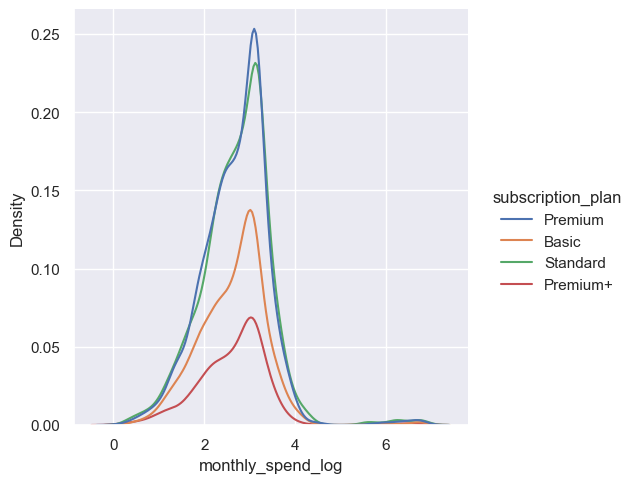

In [175]:
sns.displot(data=train, x='monthly_spend_log', hue='subscription_plan', kind='kde')

In [176]:
train['household_size_missing'] = train['household_size'].isna().astype(int)
test['household_size_missing'] = test['household_size'].isna().astype(int)

train['household_size'] = train['household_size'].fillna(0)
test['household_size'] = test['household_size'].fillna(0)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\386311482.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['household_size_missing'] = train['household_size'].isna().astype(int)
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\386311482.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['household_size'] = train['household_size'].fillna(0)


## 인코딩
- 범주형 데이터: gender, country, state_province, subscription_plan, primary_device,

In [177]:
orig_train, orig_test = train.copy(), test.copy()

In [178]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [179]:
# subscription_plan
oe = OrdinalEncoder(categories=[['Basic', 'Standard', 'Premium', 'Premium+']])

train['subscription_plan'] = oe.fit_transform(train[['subscription_plan']])
test['subscription_plan'] = oe.transform(test[['subscription_plan']])

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\2339728426.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['subscription_plan'] = oe.fit_transform(train[['subscription_plan']])


In [180]:
# 날짜 처리
train['subscription_start_date'] = pd.to_datetime(train['subscription_start_date'])
test['subscription_start_date'] = pd.to_datetime(test['subscription_start_date'])

for df in [train, test]:
    df['start_year'] = df['subscription_start_date'].dt.year
    df['start_month'] = df['subscription_start_date'].dt.month
    df['start_day'] = df['subscription_start_date'].dt.day
    df['start_weekday'] = df['subscription_start_date'].dt.weekday

train = train.drop(columns=['subscription_start_date'])
test = test.drop(columns=['subscription_start_date'])

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\798199662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['subscription_start_date'] = pd.to_datetime(train['subscription_start_date'])
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\798199662.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['start_year'] = df['subscription_start_date'].dt.year
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\798199662.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [181]:
# 나머지 범주형 원핫
cat_cols = ['gender', 'country', 'state_province', 'primary_device']

train = pd.get_dummies(train, columns=cat_cols, drop_first=False)
test = pd.get_dummies(test, columns=cat_cols, drop_first=False)

In [182]:
train

,user_id,age,subscription_plan,monthly_spend,household_size,churned,monthly_spend_log,household_size_missing,start_year,start_month,...,state_province_Texas,state_province_Virginia,state_province_Washington,state_province_Wisconsin,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet
7550,7551,22.0,2.0,10.910000,3.0,0,2.477378,0,2025,3,...,False,False,False,False,False,False,False,True,False,False
4916,4917,21.0,0.0,3.850000,3.0,0,1.578979,0,2024,1,...,False,False,False,False,False,False,False,False,True,False
5426,5427,34.0,1.0,33.070000,4.0,0,3.528417,0,2024,1,...,False,False,False,False,False,False,True,False,False,False
8420,8421,58.0,1.0,5.530000,0.0,0,1.876407,1,2025,7,...,False,False,False,False,False,False,False,False,True,False
722,723,20.0,2.0,26.010000,2.0,0,3.296207,0,2023,10,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3553,3554,31.0,2.0,3.270000,1.0,0,1.451614,0,2023,2,...,False,False,False,False,False,False,False,True,False,False
3779,3780,44.0,1.0,12.390000,6.0,0,2.594508,0,2025,5,...,False,False,False,False,False,False,False,False,False,True
7618,7619,40.0,1.0,17.250000,1.0,0,2.904165,0,2024,7,...,False,False,False,False,False,False,True,False,False,False
9621,9622,25.0,0.0,10.200000,2.0,0,2.415914,0,2024,7,...,False,False,False,False,True,False,False,False,False,False


## Baseline Model V0

In [183]:
train.shape, test.shape, test.shape[0] / train.shape[0]

((6769, 53), (1710, 53), 0.2526222484857438)

In [184]:
from sklearn.tree import DecisionTreeClassifier

y_train = train['churned']
X_train = train.drop('churned', axis=1)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


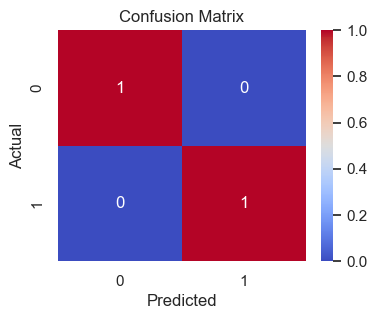

In [185]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve, confusion_matrix

# 예측
y_pred = model.predict(X_train)

# 기본 성능
print("Accuracy:", accuracy_score(y_train, y_pred))
print("Precision:", precision_score(y_train, y_pred))
print("Recall:", recall_score(y_train, y_pred))
print("F1:", f1_score(y_train, y_pred))

cm = confusion_matrix(y_train, y_pred, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Train ROC-AUC: 1.0


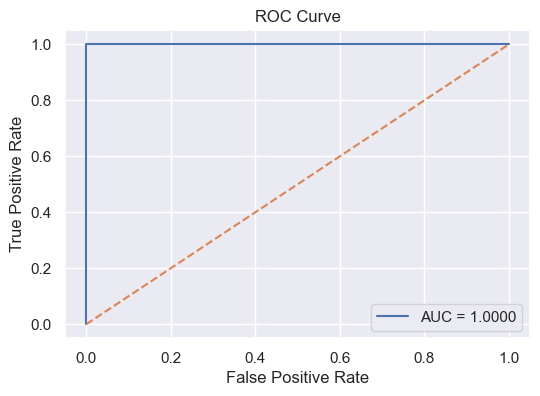

In [186]:
y_pred_proba = model.predict_proba(X_train)[:, 1]

auc = roc_auc_score(y_train, y_pred_proba)
print("Train ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Test Accuracy: 0.7543859649122807
Test F1: 0.1796875


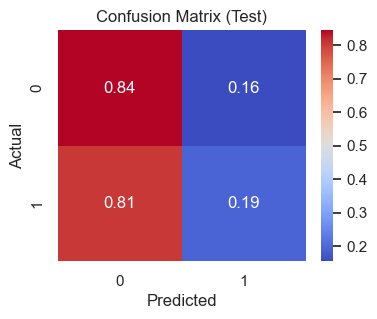

In [187]:
y_test = test['churned']
X_test = test.drop('churned', axis=1)

y_pred_test = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

Test ROC-AUC: 0.5193138948327275


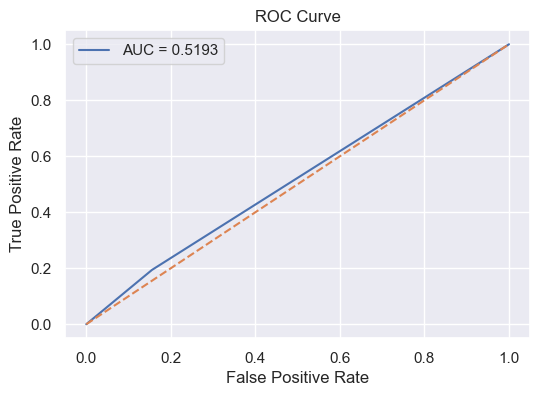

In [188]:
y_test = test['churned']
X_test = test.drop('churned', axis=1)

y_test_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Baseline model v1

### Feature Engineering

In [189]:
orig_train.shape, train.shape

((6769, 13), (6769, 53))

### Feature Engineering

In [190]:
orig_train.shape, train.shape

((6769, 13), (6769, 53))

#### 추천 클릭률

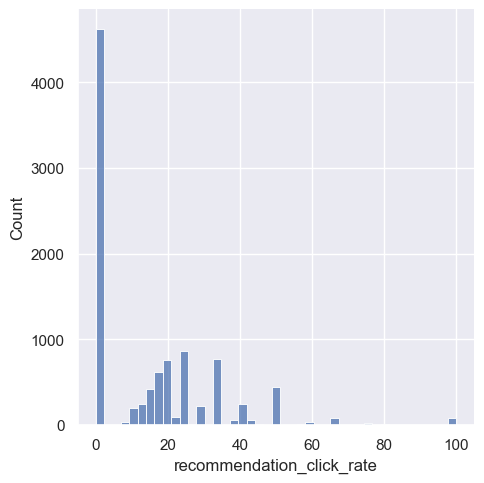

In [191]:
rec_tmp = rec_df[['user_id', 'recommendation_id', 'was_clicked']]
df_rec_click_rate = rec_tmp.groupby('user_id', as_index=False).agg(recommendation_click_rate=('was_clicked', 'mean')) * 100

sns.displot(df_rec_click_rate, x='recommendation_click_rate')

(6769, 54) (1710, 54)
recommendation_click_rate
0      6735
25        7
16        6
20        4
33        4
50        4
22        2
14        1
23        1
28        1
66        1
18        1
100       1
30        1
Name: count, dtype: int64


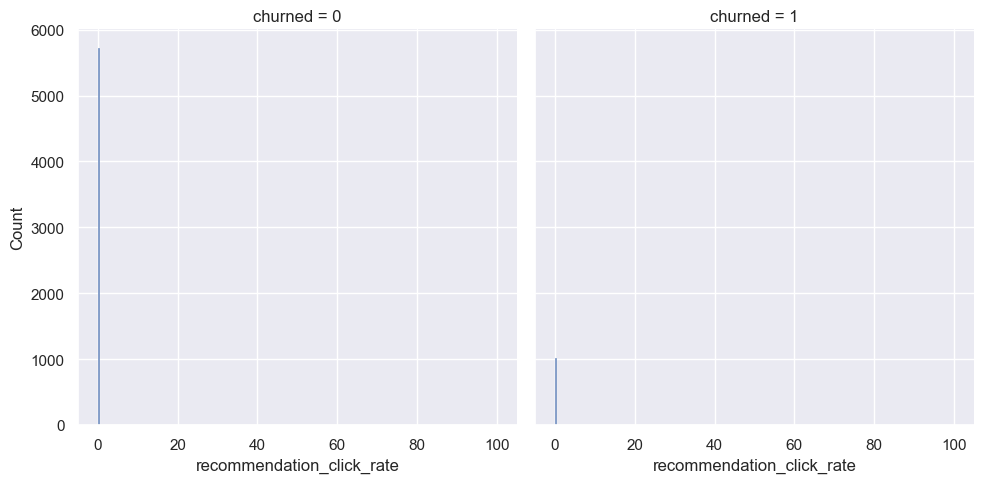

In [192]:
rec_click_rate_map = df_rec_click_rate.set_index('user_id')['recommendation_click_rate']
train['recommendation_click_rate'] = train['user_id'].map(rec_click_rate_map).fillna(0).astype(int)
test['recommendation_click_rate'] = test['user_id'].map(rec_click_rate_map).fillna(0).astype(int)

print(train.shape, test.shape)
print(train.recommendation_click_rate.value_counts())

sns.displot(data=train, x='recommendation_click_rate', col='churned')

#### 컨텐츠 상호작용

In [193]:
review_count = review_df.groupby('user_id')['review_id'].count().to_dict()
rec_click_count = rec_df.groupby('user_id')['was_clicked'].sum().to_dict()
search_count = search_df.groupby('user_id')['clicked_result_position'].sum().to_dict()

In [194]:
train['review_count'] = train['user_id'].map(review_count)#.fillna(0)
train['rec_click_count'] = train['user_id'].map(rec_click_count)#.fillna(0)
train['search_count'] = train['user_id'].map(search_count)#.fillna(0)
train['num_content_interaction'] = train['review_count'] + train['rec_click_count'] + train['search_count']

test['review_count'] = test['user_id'].map(review_count)#.fillna(0)
test['rec_click_count'] = test['user_id'].map(rec_click_count)#.fillna(0)
test['search_count'] = test['user_id'].map(search_count)#.fillna(0)
test['num_content_interaction'] = test['review_count'] + test['rec_click_count'] + test['search_count']

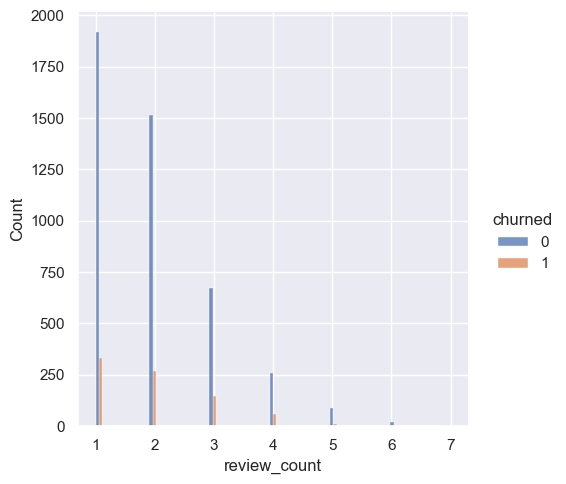

In [195]:
sns.displot(data=train, x='review_count', hue='churned', multiple='dodge')

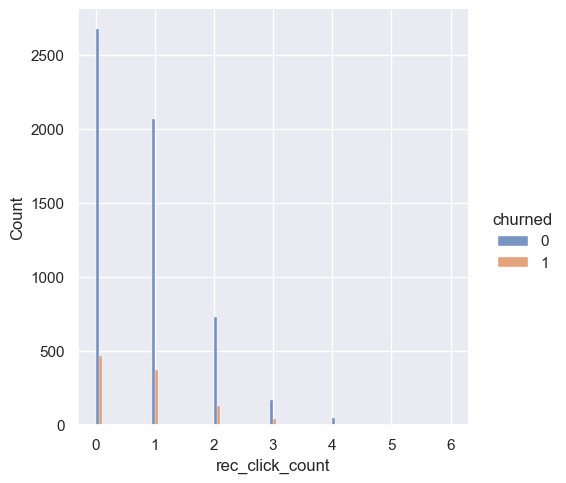

In [196]:
sns.displot(data=train, x='rec_click_count', hue='churned', multiple='dodge')

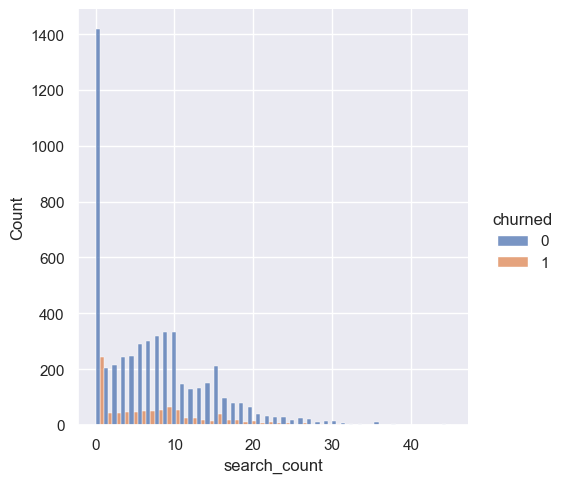

In [197]:
sns.displot(data=train, x='search_count', hue='churned', multiple='dodge', )

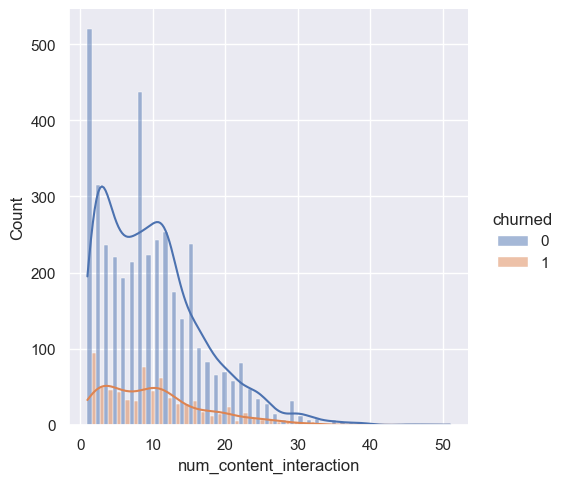

In [198]:
sns.displot(data=train, x='num_content_interaction', hue='churned', multiple='dodge', kde=True,)

#### 평점

In [199]:
mean_rating = review_df.groupby('user_id')['rating'].mean()
train['mean_rating_given'] = train['user_id'].map(mean_rating) #.fillna(0)
test['mean_rating_given'] = test['user_id'].map(mean_rating)

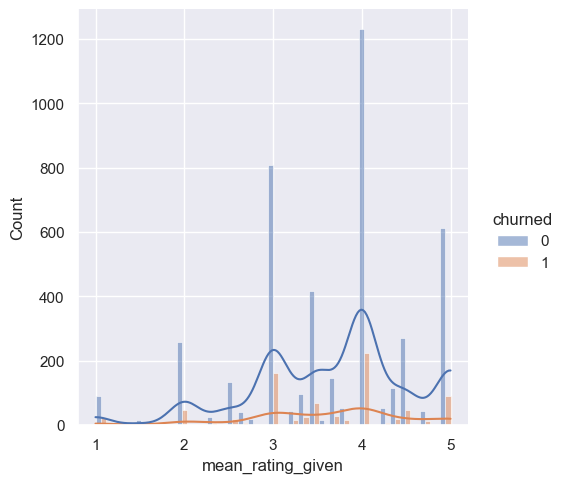

In [200]:
sns.displot(data=train, x='mean_rating_given', hue='churned', multiple='dodge', kde=True, ) # stat='probability', common_norm=False

#### 시청 완료율

In [201]:
watch_tmp = watch_df[['user_id', 'progress_percentage', 'action']]
watch_tmp['is_completed'] = (watch_tmp['action'].astype(str).str.lower() == 'completed') | (watch_tmp['progress_percentage'] >= 100)

train['completion_rate'] = (watch_tmp.groupby('user_id')['is_completed'].mean()*100)
train['completion_rate'] = train['completion_rate'].fillna(0)

test['completion_rate'] = (watch_tmp.groupby('user_id')['is_completed'].mean()*100)
test['completion_rate'] = test['completion_rate'].fillna(0)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\2922065899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_tmp['is_completed'] = (watch_tmp['action'].astype(str).str.lower() == 'completed') | (watch_tmp['progress_percentage'] >= 100)


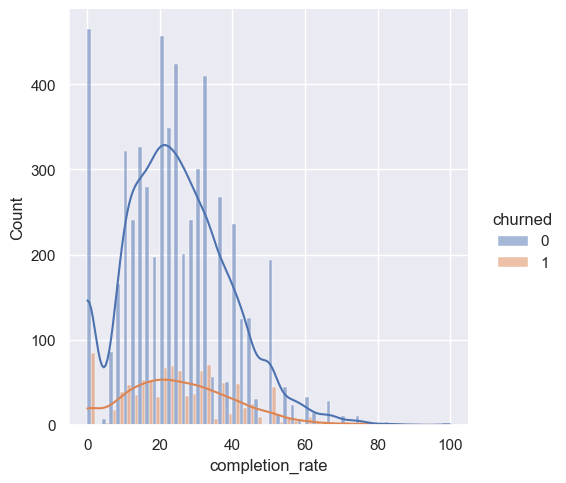

In [202]:
sns.displot(data=train, x='completion_rate', hue='churned', kde=True, multiple='dodge')

#### 주간 평균 시청 수

In [203]:
watch_tmp = watch_df[['user_id', 'session_id', 'watch_date']]
watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
watch_tmp['watch_week'] = watch_tmp['watch_date'].dt.to_period('W')

weekly_session = watch_tmp.groupby(['user_id', 'watch_week'])['session_id'].nunique().reset_index(name='weekly_session_count')
watch_sessions_per_week_map = weekly_session.groupby('user_id')['weekly_session_count'].mean()

train['watch_sessions_per_week'] = train['user_id'].map(watch_sessions_per_week_map)# .fillna(0)
test['watch_sessions_per_week'] = test['user_id'].map(watch_sessions_per_week_map)# .fillna(0)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\928061762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\928061762.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_tmp['watch_week'] = watch_tmp['watch_date'].dt.to_period('W')


In [204]:
train['watch_sessions_per_week'].value_counts()

watch_sessions_per_week
1.000000    4365
1.111111     272
1.100000     247
1.125000     237
1.090909     200
1.142857     200
1.083333     199
1.166667     173
1.076923     127
1.200000     115
1.071429      99
1.250000      81
1.181818      66
1.066667      55
1.222222      50
1.062500      44
1.153846      37
1.333333      30
1.058824      26
1.285714      26
1.133333      24
1.117647      13
1.272727      11
1.500000       9
1.300000       8
1.230769       7
1.055556       6
1.400000       6
1.214286       5
1.052632       5
1.157895       4
1.375000       3
1.428571       3
1.307692       3
1.187500       3
1.363636       2
1.571429       2
1.384615       1
1.266667       1
1.750000       1
1.105263       1
1.666667       1
1.444444       1
Name: count, dtype: int64

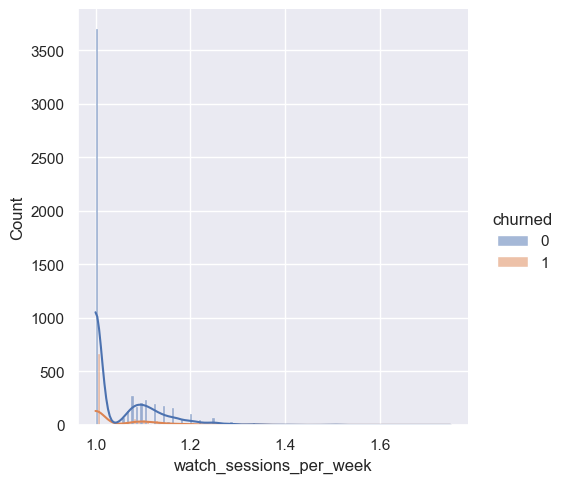

In [205]:
sns.displot(train, x='watch_sessions_per_week',  hue='churned', kde=True, multiple='dodge')

#### 일평균 시청 시간

In [206]:
watch_tmp = watch_df[['user_id', 'watch_date', 'watch_duration_minutes']]
watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')

# 3. user별, 날짜별 총 시청 시간 계산
daily_watch = (
    watch_tmp
    .groupby(['user_id', 'watch_date'])['watch_duration_minutes']
    .sum()
    .reset_index(name='daily_watch_minutes')
)

# 4. user별 하루 평균 시청 시간 계산 -> 반올림 -> int
avg_watch_time_map = (
    daily_watch
    .groupby('user_id')['daily_watch_minutes']
    .mean()
    .round(0)
    .astype(int)
    .to_dict()
)

train['avg_watch_time_minutes'] = train['user_id'].map(avg_watch_time_map)
test['avg_watch_time_minutes'] = test['user_id'].map(avg_watch_time_map)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23744\1322611040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')


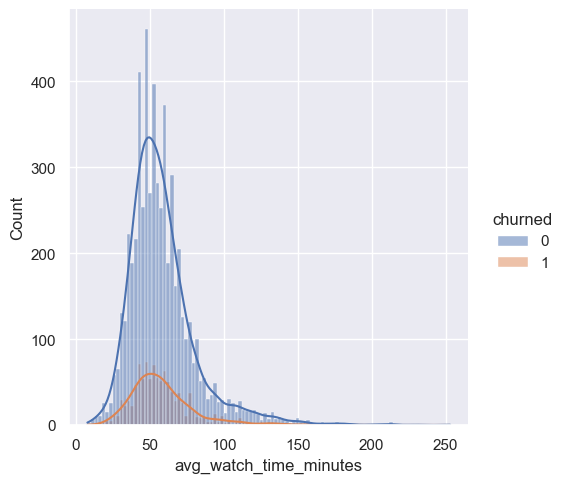

In [207]:
sns.displot(train, x='avg_watch_time_minutes', hue='churned', kde=True) # stat='probability', common_norm=False

#### favorite genre

In [208]:
watch_tmp = watch_df[['user_id', 'movie_id']]
movie_tmp = movie_df[['movie_id', 'genre_primary']]
watch_genre = watch_tmp.merge(
            movie_tmp,
            on='movie_id',
            how='left'
        )

favorite_genre_map = (
            watch_genre
            .groupby('user_id')['genre_primary']
            .agg(lambda x: x.dropna().value_counts().idxmax() if not x.dropna().empty else None)
            .to_dict()
        )

train['favorite_genre'] = train['user_id'].map(favorite_genre_map)
test['favorite_genre'] = test['user_id'].map(favorite_genre_map)

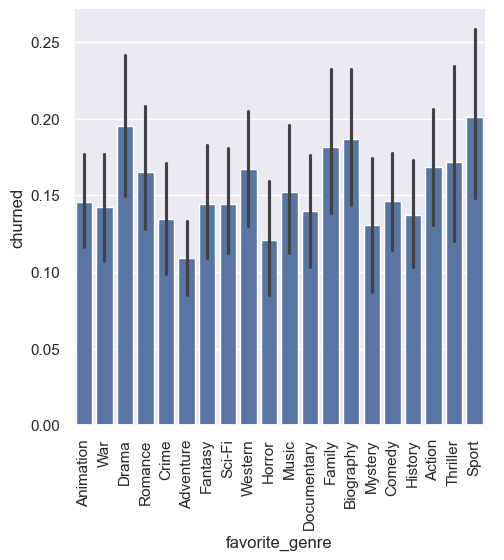

In [209]:
sns.catplot(train, x='favorite_genre', y='churned', kind='bar')
plt.xticks(rotation=90)
plt.show()

#### 마지막 활동 일자

In [210]:
watch_activity = watch_df[['user_id', 'watch_date']]
watch_activity = watch_activity.rename(columns={'watch_date': 'activity_date'})
watch_activity['activity_date'] = pd.to_datetime(watch_activity['activity_date'])

search_activity = search_df[['user_id', 'search_date']]
search_activity = search_activity.rename(columns={'search_date': 'activity_date'})
search_activity['activity_date'] = pd.to_datetime(search_activity['activity_date'])

review_activity = review_df[['user_id', 'review_date']]
review_activity = review_activity.rename(columns={'review_date': 'activity_date'})
review_activity['activity_date'] = pd.to_datetime(review_activity['activity_date'])

activity_logs = pd.concat([watch_activity, search_activity, review_activity], axis=0, ignore_index=True)
df_final_activity = activity_logs.groupby('user_id')['activity_date'].max()

train['final_activity_date'] = train['user_id'].map(df_final_activity)
test['final_activity_date'] = test['user_id'].map(df_final_activity)

### 피처 선택 및 인코딩

In [211]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6769 entries, 7550 to 3206
Data columns (total 64 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   user_id                                   6769 non-null   int64         
 1   age                                       6769 non-null   float64       
 2   subscription_plan                         6769 non-null   float64       
 3   monthly_spend                             6769 non-null   float64       
 4   household_size                            6769 non-null   float64       
 5   churned                                   6769 non-null   int64         
 6   monthly_spend_log                         6769 non-null   float64       
 7   household_size_missing                    6769 non-null   int64         
 8   start_year                                6769 non-null   int32         
 9   start_month                     

In [212]:
print(train.columns.tolist()[53:59])

['recommendation_click_rate', 'review_count', 'rec_click_count', 'search_count', 'num_content_interaction', 'mean_rating_given']


<Axes: >

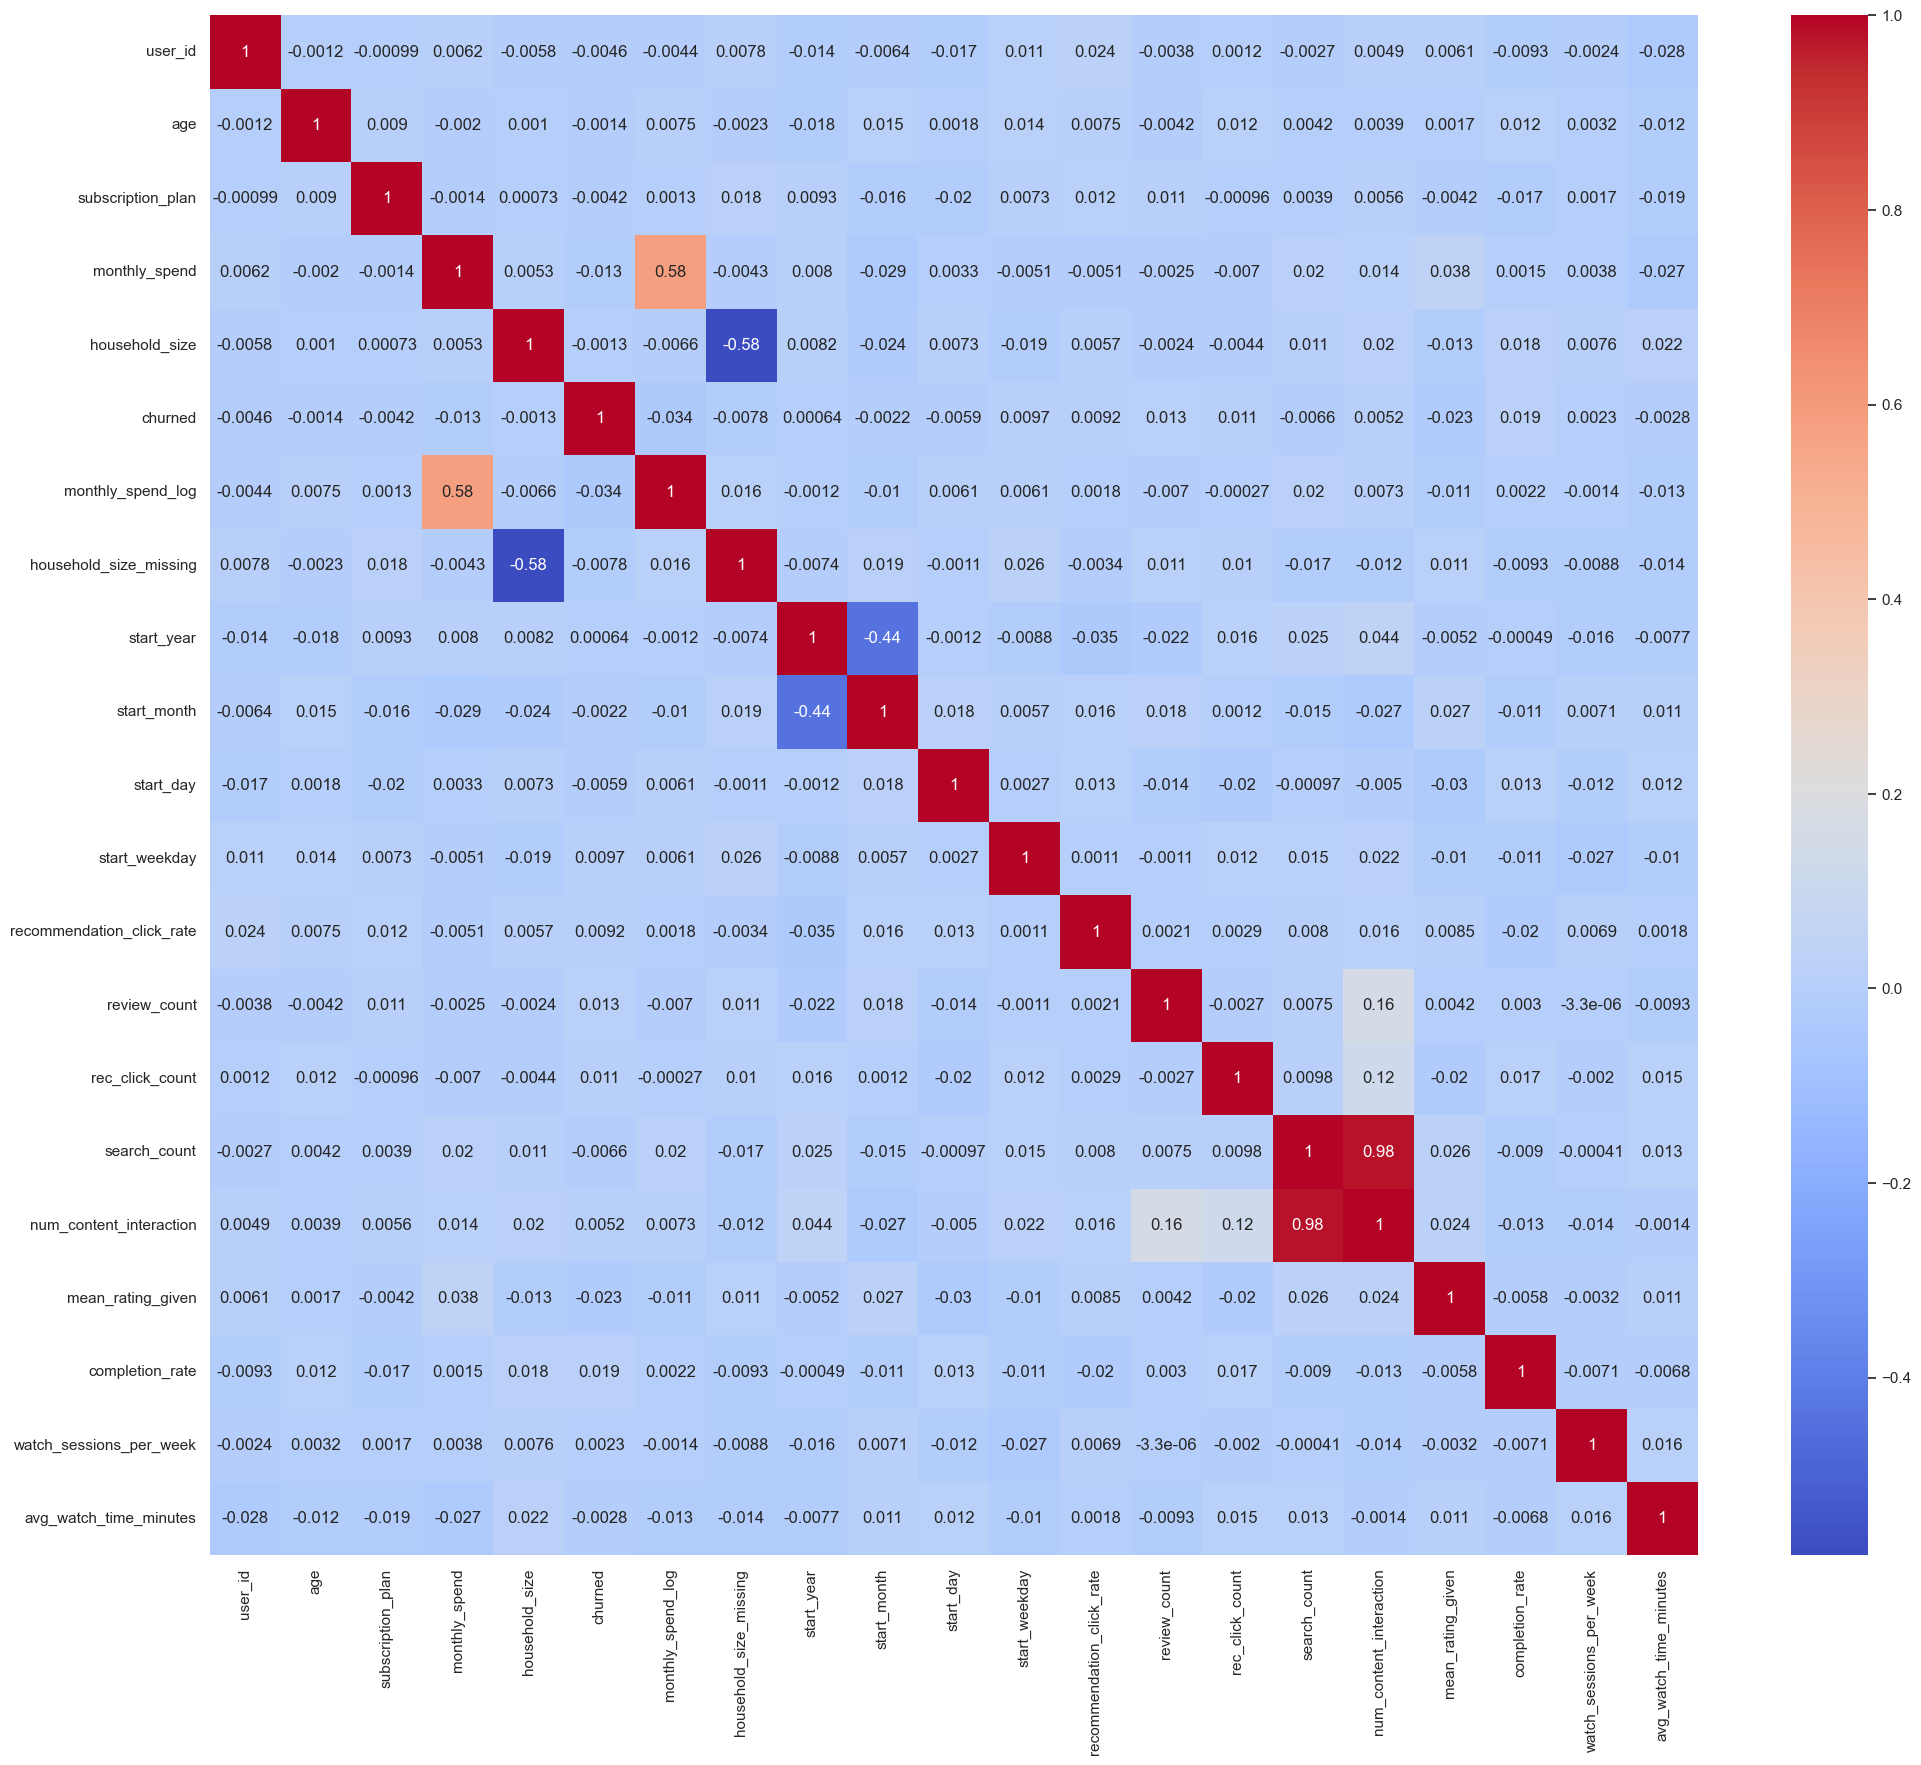

In [213]:
plt.figure(figsize=(24, 20))
sns.heatmap(train.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

In [214]:
y_train = train['churned']
y_test = test['churned']
X_train = train.drop(columns=['churned', 'user_id', 'recommendation_click_rate', 'review_count', 'rec_click_count', 'search_count', 'num_content_interaction', 'mean_rating_given'])
X_test = test.drop(columns=['churned', 'user_id', 'recommendation_click_rate', 'review_count', 'rec_click_count', 'search_count', 'num_content_interaction', 'mean_rating_given'])

In [215]:
# 날짜 처리
X_train['final_activity_date'] = pd.to_datetime(X_train['final_activity_date'])
X_test['final_activity_date'] = pd.to_datetime(X_test['final_activity_date'])

for df in [X_train, X_test]:
    df['final_year'] = df['final_activity_date'].dt.year
    df['final_month'] = df['final_activity_date'].dt.month
    df['final_day'] = df['final_activity_date'].dt.day
    df['final_weekday'] = df['final_activity_date'].dt.weekday

X_train = X_train.drop(columns=['final_activity_date'])
X_test = X_test.drop(columns=['final_activity_date'])

In [216]:
# 나머지 범주형 원핫
cat_cols = ['favorite_genre',]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

In [217]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Test Accuracy: 0.7391812865497076
Test F1: 0.14559386973180077


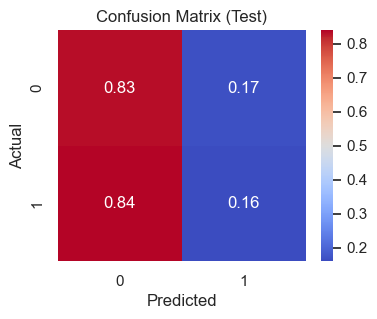

In [218]:
y_pred_test = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

Test ROC-AUC: 0.4963262780685246


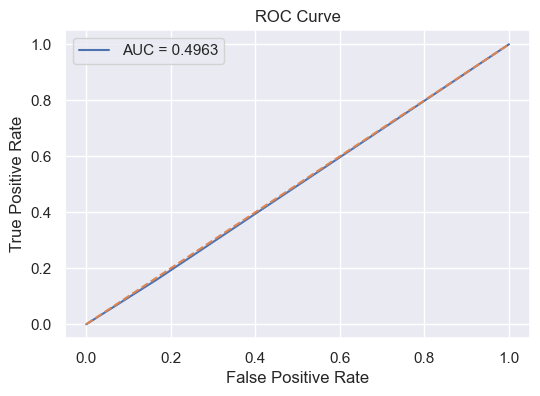

In [219]:
y_test_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Baseline model V2

In [220]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)

<Axes: xlabel='churned', ylabel='count'>

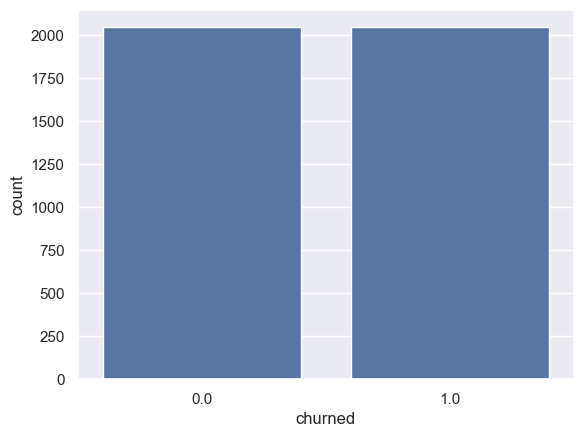

In [221]:
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
sns.countplot(pd.concat([X_resampled, y_resampled]), x='churned')

In [222]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Test Accuracy: 0.4830409356725146
Test F1: 0.19636363636363635


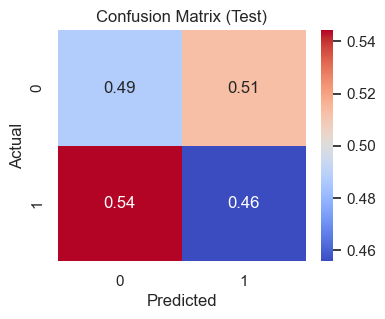

In [223]:
y_pred_test = model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

Test ROC-AUC: 0.4715683999759382


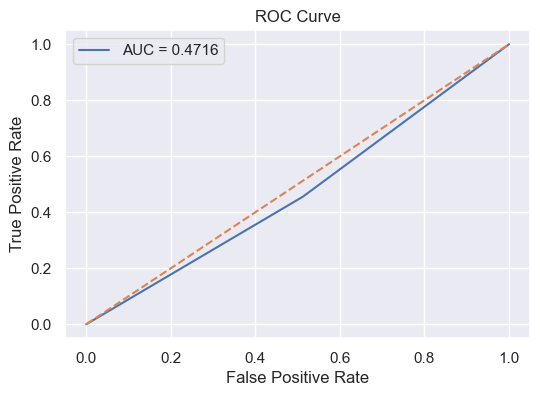

In [224]:
y_test_proba = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Other Models

In [225]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
lgbm = LGBMClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

dt.fit(X_resampled, y_resampled)
xgb.fit(X_resampled, y_resampled)
lgbm.fit(X_resampled, y_resampled)
rf.fit(X_resampled, y_resampled)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1023, number of negative: 1023
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1005
[LightGBM] [Info] Number of data points in the train set: 2046, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Test Accuracy: 0.4830409356725146
Test F1: 0.19636363636363635


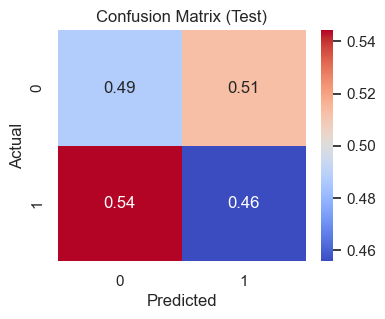

Test ROC-AUC: 0.4715683999759382


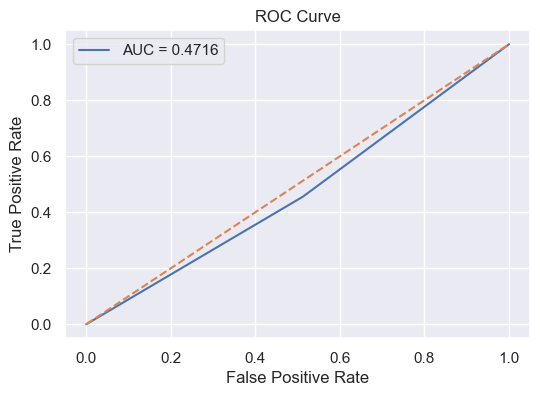

In [226]:
y_pred_test = dt.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

y_test_proba = dt.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Test Accuracy: 0.5058479532163743
Test F1: 0.21395348837209302


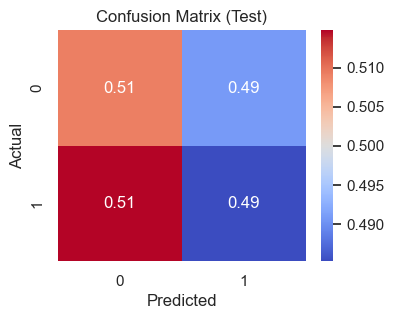

Test ROC-AUC: 0.48848184336338196


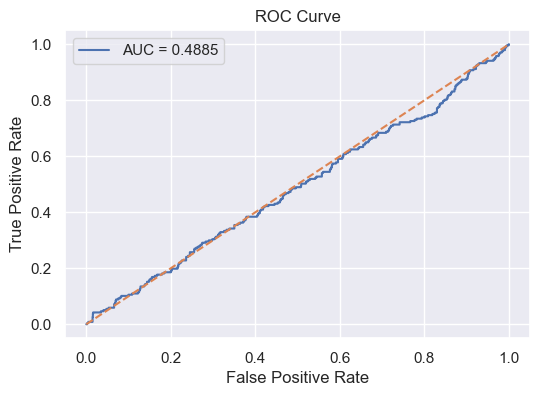

In [227]:
y_pred_test = xgb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

y_test_proba = xgb.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Test Accuracy: 0.4935672514619883
Test F1: 0.21415607985480944


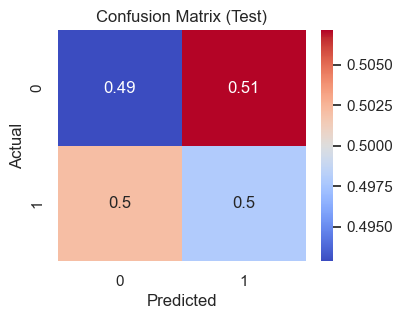

Test ROC-AUC: 0.49271127839794215


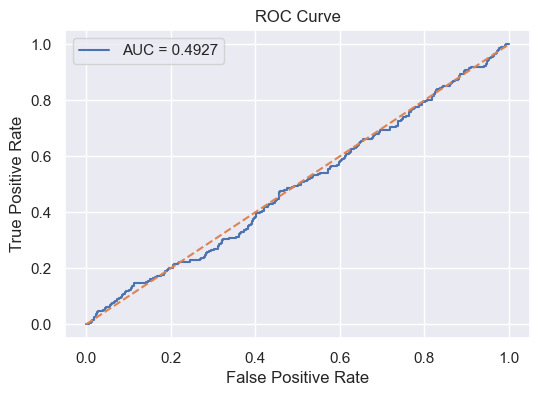

In [228]:
y_pred_test = lgbm.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

y_test_proba = lgbm.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Test Accuracy: 0.5245614035087719
Test F1: 0.22200956937799043


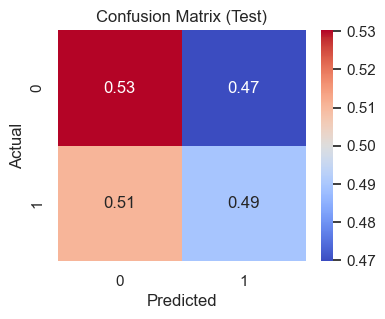

Test ROC-AUC: 0.5041320420164938


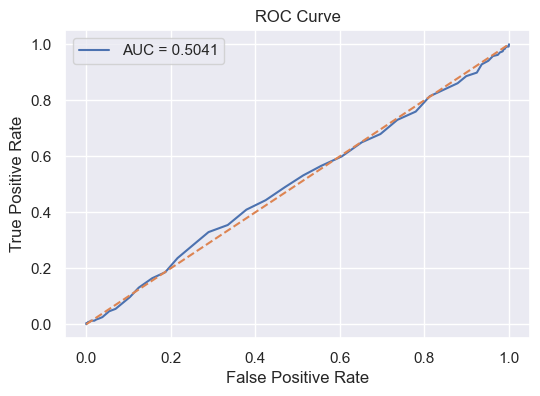

In [229]:
y_pred_test = rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test F1:", f1_score(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test, normalize='true')

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, cmap='coolwarm')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test)")
plt.show()

y_test_proba = rf.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC:", test_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()